In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries installed successfully!")

All libraries installed successfully!


In [13]:
df = pd.read_csv("Sample_Superstore.csv")

df.head()

,A`,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,4962,CA-2016-156587,7-3-2016,8-3-2016,First Class,AB-10015,Aaron Bergman,Consumer,United States,Seattle,...,98103.0,West,FUR-CH-10004477,Furniture,Chairs,"Global Push Button Manager's Chair, Indigo",48.712,1,0.2,5.4801
1,4963,CA-2016-156587,7-3-2016,8-3-2016,First Class,AB-10015,Aaron Bergman,Consumer,United States,Seattle,...,98103.0,West,OFF-AR-10001427,Office Supplies,Art,Newell 330,17.940,3,0.0,4.6644
2,4964,CA-2016-156587,7-3-2016,8-3-2016,First Class,AB-10015,Aaron Bergman,Consumer,United States,Seattle,...,98103.0,West,OFF-ST-10002344,Office Supplies,Storage,"Carina 42""Hx23 3/4""W Media Storage Unit",242.940,3,0.0,4.8588
3,8223,CA-2016-152905,18-2-2016,24-2-2016,Standard Class,AB-10015,Aaron Bergman,Consumer,United States,Arlington,...,76017.0,Central,OFF-ST-10000321,Office Supplies,Storage,Akro Stacking Bins,12.624,2,0.2,-2.5248
4,8802,CA-2018-140935,10-11-2018,12-11-2018,First Class,AB-10015,Aaron Bergman,Consumer,United States,Oklahoma City,...,73120.0,Central,TEC-PH-10000562,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544


In [14]:
# Check shape
print("Rows and Columns:", df.shape)

# Column info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

Rows and Columns: (9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   A`              9994 non-null   int64  
 1   Order ID        9994 non-null   str    
 2   Order Date      9994 non-null   str    
 3   Ship Date       9994 non-null   str    
 4   Ship Mode       9994 non-null   str    
 5   Customer ID     9994 non-null   str    
 6   Customer Name   9994 non-null   str    
 7   Segment         9994 non-null   str    
 8   Country/Region  9994 non-null   str    
 9   City            9994 non-null   str    
 10  State           9994 non-null   str    
 11  Postal Code     9983 non-null   float64
 12  Region          9994 non-null   str    
 13  Product ID      9994 non-null   str    
 14  Category        9994 non-null   str    
 15  Sub-Category    9994 non-null   str    
 16  Product Name    9994 non-null   str    
 17  Sales          

A`                 0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [15]:
df = df.drop_duplicates()

In [16]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [18]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed", dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed", dayfirst=True)

In [19]:
print("Total Sales:",df["Sales"].sum())
print("Total Profit",df["Profit"].sum())

Total Sales: 2297200.8603
Total Profit 286397.0217


In [10]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


In [20]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


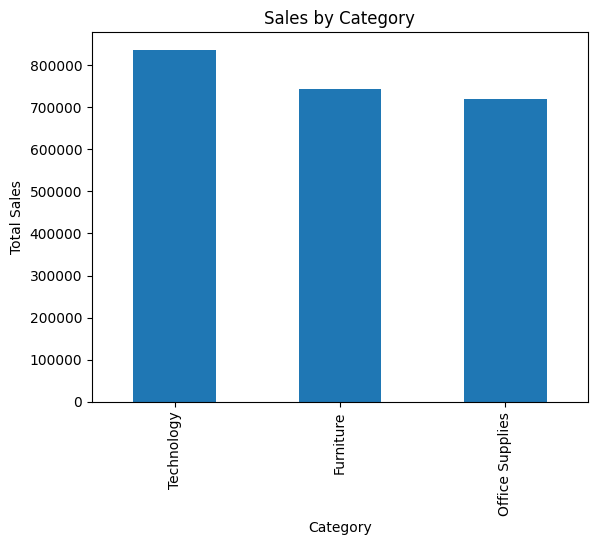

In [21]:
plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [33]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['A`', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country/Region', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')


In [35]:
df = df.rename(columns={"A`": "Row ID"})
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')


In [36]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

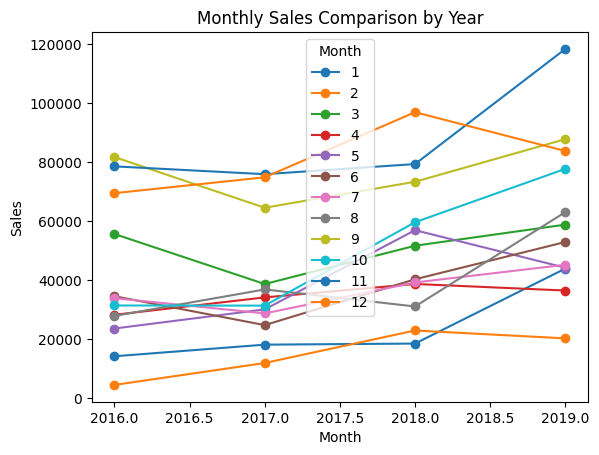

In [42]:
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().unstack()

monthly_sales.plot(marker='o')
plt.title("Monthly Sales Comparison by Year")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [43]:
df.to_csv("cleaned_superstore.csv", index=False)